## Analyse du portefeuille

#### Setup du workspace

In [10]:
# Import des librairies standard
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [11]:
# Import des librairies DS
import spacy
import sklearn

In [12]:
# Import des modules perso
import sys
parent_dir = os.path.abspath('..')
sys.path.append(parent_dir)

from utils import TransformData

In [13]:
# Defining workspace
base_directory = '/home/onyxia/work/project'
data_directory = os.path.join(base_directory, '1-data')
data_training_directory = os.path.join(data_directory, 'training')
data_test_directory = os.path.join(data_directory, 'test')
data_evaluation_directory = os.path.join(data_directory, 'evaluation')
data_additional_directory = os.path.join(data_directory, 'additional')
eda_directory = os.path.join(base_directory, '2-eda')
models_directory = os.path.join(base_directory, '3-models')

In [14]:
# Defining files
!pip install openpyxl
file_conso = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_consommations_2023_11.csv", sep=";")
file_portfeuille = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")
file_interaction = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_interactions_2023_11.csv", sep=";")
file_impayes = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_impayes_2023_11.csv", sep=";")
file_reclamations = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_reclamations_2023_11.csv", sep=";")
file_dictionnaire = pd.read_excel("s3://projet-bdc-data/alptis/data_challenges_ensae_alptis_dictionnaire_donnees.xlsx", sheet_name='portefeuille')


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


/tmp/ipykernel_646318/2399039523.py:4: DtypeWarning: Columns (31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  file_portfeuille = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")


#### Defining initial data structures


In [16]:
# Dataframes
df_portfolio = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")
df_conso = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_consommations_2023_11.csv", sep=";")
df_interaction = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_interactions_2023_11.csv", sep=";")
df_reclamation = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_reclamations_2023_11.csv", sep=";")
df_impaye = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_impayes_2023_11.csv", sep=";")

# Lists columns
col_portfolio = list(df_portfolio.columns)
col_conso = list(df_conso.columns)
col_interaction = list(df_interaction.columns)
col_reclamation = list(df_reclamation.columns)
col_impaye = list(df_impaye.columns)

# Dictionnaire de variables
with TransformData.FileManager("s3://projet-bdc-data/alptis/data_challenges_ensae_alptis_dictionnaire_donnees.xlsx", "portefeuille") as file:
    variable_dictionnary_portfolio = dict(zip(file.iloc[:,0], file.iloc[:,1]))

/tmp/ipykernel_646318/1048647307.py:2: DtypeWarning: Columns (31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df_portfolio = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")


#### Overview

The goal of this section is to build an in-depth understanding of the data structure. This job encompasses :
-   Analyze the size of the dataset
-   The data type issues (categorical variables considered as numeric or vice-versa)
-   Evaluate the extent and impact of missing values and strategies to deal with them
-   Analyze the distribution of variables and strategies to group them in a coherent manner
-   Visualize variables individually

**Dataset structure**

In [17]:
# Describe the dataset
df_portfolio.shape

(132576, 47)

-   The portfolio dataset contains one line per client. We have a total of 132 576 clients from whose we collect 46 variables (including the ID) and the target variables.

In [18]:
# Describe the dataset
df_portfolio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132576 entries, 0 to 132575
Data columns (total 47 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   client_code                                  132576 non-null  int64  
 1   client_age_souscripteur                      132576 non-null  int64  
 2   client_sexe_souscripteur                     132576 non-null  object 
 3   client_ro_souscripteur                       132576 non-null  object 
 4   client_code_postal                           132576 non-null  int64  
 5   client_departement                           132576 non-null  int64  
 6   client_departement_avant_changement_12_mois  465 non-null     float64
 7   client_a_conjoint                            132576 non-null  float64
 8   client_nb_enfants                            132576 non-null  float64
 9   client_structure_familiale                   132576 non-nul

In [19]:
# Describe the dataset
TransformData.grouptype(df_portfolio)

{'int64': ['client_code',
  'client_age_souscripteur',
  'client_code_postal',
  'client_departement',
  'client_a_garantie_prevoyance',
  'client_est_contrat_madelin',
  'client_anciennete_contrat_annees',
  'client_cotisations_annualisees_n_plus1',
  'courtier_code_partenaire',
  'courtier_code_apporteur',
  'courtier_est_escompte',
  'courtier_nb_affaires_n_moins1',
  'courtier_nb_radiations_n_moins1',
  'courtier_nb_affaires_n_moins2',
  'courtier_nb_radiations_n_moins2',
  'target_resiliation_6mois'],
 'object': ['client_sexe_souscripteur',
  'client_ro_souscripteur',
  'client_structure_familiale',
  'client_produit',
  'client_garantie_base',
  'client_garantie_base_plus_options',
  'client_millesime_tarifaire_produit',
  'client_zone_tarifaire',
  'client_type_zone_tarifaire',
  'client_date_debut_effet_garantie',
  'client_mode_paiement',
  'client_frequence_paiement',
  'client_nom_banque',
  'client_nps_date_reponse_n',
  'client_nps_verbatim_n',
  'client_nps_date_reponse_n

Raw dataset contains three types of data :
-   *int* : Some of them are pure int variables. The other are categorical variables described with numeric values. We need to categorize them for the sake of analysis
-   *float64* : The scheme is the same. Some variables are pure floats, some other should be classified integer and the remaining as categorical.
-   *object* : These are native categorical variables.

In [20]:
# Format the variables
df_portfolio['client_code'] = df_portfolio['client_code'].astype(str)
df_portfolio['client_code_postal'] = df_portfolio['client_code_postal'].astype(str).str.zfill(5)
df_portfolio['client_departement'] = df_portfolio['client_departement'].astype(str).str.zfill(2)
df_portfolio['client_departement_avant_changement_12_mois'] = df_portfolio['client_departement_avant_changement_12_mois'].astype(str)
df_portfolio['client_a_garantie_prevoyance'] = df_portfolio['client_a_garantie_prevoyance'].astype(str)
df_portfolio['client_est_contrat_madelin'] = df_portfolio['client_est_contrat_madelin'].astype(str)
df_portfolio['courtier_est_escompte'] = df_portfolio['courtier_est_escompte'].astype(str)
df_portfolio['client_a_conjoint'] = df_portfolio['client_a_conjoint'].astype(str)
df_portfolio['courtier_code_partenaire'] = df_portfolio['courtier_code_partenaire'].astype(str)
df_portfolio['courtier_code_apporteur'] = df_portfolio['courtier_code_apporteur'].astype(str)
df_portfolio['courtier_code_avant_changement_12_mois'] = df_portfolio['courtier_code_avant_changement_12_mois'].astype(str)
df_portfolio['client_nb_enfants'] = df_portfolio['client_nb_enfants'].astype(int)
df_portfolio['client_nb_assures_contrat'] = df_portfolio['client_nb_assures_contrat'].astype(int)

# running data type analysis
TransformData.grouptype(df_portfolio)

{'object': ['client_code',
  'client_sexe_souscripteur',
  'client_ro_souscripteur',
  'client_code_postal',
  'client_departement',
  'client_departement_avant_changement_12_mois',
  'client_a_conjoint',
  'client_structure_familiale',
  'client_a_garantie_prevoyance',
  'client_produit',
  'client_garantie_base',
  'client_garantie_base_plus_options',
  'client_millesime_tarifaire_produit',
  'client_zone_tarifaire',
  'client_type_zone_tarifaire',
  'client_est_contrat_madelin',
  'client_date_debut_effet_garantie',
  'client_mode_paiement',
  'client_frequence_paiement',
  'client_nom_banque',
  'client_nps_date_reponse_n',
  'client_nps_verbatim_n',
  'client_nps_date_reponse_n_moins1',
  'client_nps_verbatim_n_moins1',
  'courtier_code_partenaire',
  'courtier_code_apporteur',
  'courtier_code_avant_changement_12_mois',
  'courtier_reseau_courtage',
  'courtier_segmentation_interne',
  'courtier_type_commission',
  'courtier_est_escompte'],
 'int64': ['client_age_souscripteur',
 

In [21]:
# These lines to deal with matching issues when merging the portfolio dataset to the cartiflette
dic_corse = {}
def create_dictionnary_of_code_insee(list_code_postal: list):
    for elem in list_code_postal:
        time.sleep(2)
        code_1 = ''
        code_2 = ''
        code_1, code_2 = TransformData.code_insee_from_communes_as_dict(code_postal=elem)
        if len(code_1) != 0 and len(code_2) != 0:
            dic_corse[code_1] = code_2[:2]
            # print(f'Le code postal {code_1} a pour code insee {code_2}')

create_dictionnary_of_code_insee(list(df_portfolio[df_portfolio['client_departement']=='20']['client_code_postal'].unique()))
df_portfolio['client_departement'] = (df_portfolio['client_code_postal'].map(dic_corse).fillna(df_portfolio['client_departement']))
df_portfolio.loc[df_portfolio["client_departement"] == "97", "client_departement"] = (df_portfolio["client_code_postal"].str[:3])

# running data type analysis
TransformData.grouptype(df_portfolio)

{'object': ['client_code',
  'client_sexe_souscripteur',
  'client_ro_souscripteur',
  'client_code_postal',
  'client_departement',
  'client_departement_avant_changement_12_mois',
  'client_a_conjoint',
  'client_structure_familiale',
  'client_a_garantie_prevoyance',
  'client_produit',
  'client_garantie_base',
  'client_garantie_base_plus_options',
  'client_millesime_tarifaire_produit',
  'client_zone_tarifaire',
  'client_type_zone_tarifaire',
  'client_est_contrat_madelin',
  'client_date_debut_effet_garantie',
  'client_mode_paiement',
  'client_frequence_paiement',
  'client_nom_banque',
  'client_nps_date_reponse_n',
  'client_nps_verbatim_n',
  'client_nps_date_reponse_n_moins1',
  'client_nps_verbatim_n_moins1',
  'courtier_code_partenaire',
  'courtier_code_apporteur',
  'courtier_code_avant_changement_12_mois',
  'courtier_reseau_courtage',
  'courtier_segmentation_interne',
  'courtier_type_commission',
  'courtier_est_escompte'],
 'int64': ['client_age_souscripteur',
 

In [22]:
df_portfolio.head(10)

,client_code,client_age_souscripteur,client_sexe_souscripteur,client_ro_souscripteur,client_code_postal,client_departement,client_departement_avant_changement_12_mois,client_a_conjoint,client_nb_enfants,client_structure_familiale,...,courtier_code_avant_changement_12_mois,courtier_reseau_courtage,courtier_segmentation_interne,courtier_type_commission,courtier_est_escompte,courtier_nb_affaires_n_moins1,courtier_nb_radiations_n_moins1,courtier_nb_affaires_n_moins2,courtier_nb_radiations_n_moins2,target_resiliation_6mois
0,21736,97,F,SS,69100,69,nan,0.0,0,femme ss enfant,...,nan,AFFAIRE DIRECTE,Alptis,NaN,0,5,44,3,51,0
1,22037,95,F,SS,26230,26,nan,0.0,0,femme ss enfant,...,140183.0,AFFAIRE DIRECTE,Alptis,NaN,0,51,26,48,21,0
2,22331,88,M,TNS,69760,69,nan,1.0,0,couple ss enfant,...,nan,AFFAIRE DIRECTE,Alptis,NaN,0,5,44,3,51,0
3,22604,95,F,TNS,69003,69,nan,0.0,0,femme ss enfant,...,140484.0,AFFAIRE DIRECTE,Alptis,NaN,0,51,26,48,21,0
4,22702,90,M,TNS,69100,69,nan,1.0,0,couple ss enfant,...,nan,AFFAIRE DIRECTE,Alptis,NaN,0,5,44,3,51,0
5,23003,91,F,TNS,69270,69,nan,0.0,0,femme ss enfant,...,nan,AFFAIRE DIRECTE,Alptis,NaN,0,5,44,3,51,0
6,23031,101,F,TNS,69153,69,nan,0.0,0,femme ss enfant,...,nan,AFFAIRE DIRECTE,Alptis,NaN,0,5,44,3,51,0
7,23164,96,M,TNS,69100,69,nan,1.0,0,couple ss enfant,...,nan,AFFAIRE DIRECTE,Alptis,NaN,0,5,44,3,51,0
8,23318,82,M,TNS,69008,69,nan,1.0,0,couple ss enfant,...,140484.0,AFFAIRE DIRECTE,Alptis,NaN,0,51,26,48,21,0
9,23633,86,M,SS,69100,69,nan,0.0,0,homme ss enfant,...,nan,AFFAIRE DIRECTE,Alptis,NaN,0,5,44,3,51,0


**Dataset overview**

In [23]:
# Print
df_portfolio.head()

,client_code,client_age_souscripteur,client_sexe_souscripteur,client_ro_souscripteur,client_code_postal,client_departement,client_departement_avant_changement_12_mois,client_a_conjoint,client_nb_enfants,client_structure_familiale,...,courtier_code_avant_changement_12_mois,courtier_reseau_courtage,courtier_segmentation_interne,courtier_type_commission,courtier_est_escompte,courtier_nb_affaires_n_moins1,courtier_nb_radiations_n_moins1,courtier_nb_affaires_n_moins2,courtier_nb_radiations_n_moins2,target_resiliation_6mois
0,21736,97,F,SS,69100,69,nan,0.0,0,femme ss enfant,...,nan,AFFAIRE DIRECTE,Alptis,NaN,0,5,44,3,51,0
1,22037,95,F,SS,26230,26,nan,0.0,0,femme ss enfant,...,140183.0,AFFAIRE DIRECTE,Alptis,NaN,0,51,26,48,21,0
2,22331,88,M,TNS,69760,69,nan,1.0,0,couple ss enfant,...,nan,AFFAIRE DIRECTE,Alptis,NaN,0,5,44,3,51,0
3,22604,95,F,TNS,69003,69,nan,0.0,0,femme ss enfant,...,140484.0,AFFAIRE DIRECTE,Alptis,NaN,0,51,26,48,21,0
4,22702,90,M,TNS,69100,69,nan,1.0,0,couple ss enfant,...,nan,AFFAIRE DIRECTE,Alptis,NaN,0,5,44,3,51,0


In [24]:
# Spliting caterorical vs numerical variables
list_categorical = df_portfolio.select_dtypes(include=["object","bool"]).columns.to_list()
list_categorical.append('target_resiliation_6mois')
list_numerical = df_portfolio.select_dtypes(exclude=["object","bool"]).columns.to_list()

In [25]:
# Spliting caterorical vs numerical variables
list_categorical

['client_code',
 'client_sexe_souscripteur',
 'client_ro_souscripteur',
 'client_code_postal',
 'client_departement',
 'client_departement_avant_changement_12_mois',
 'client_a_conjoint',
 'client_structure_familiale',
 'client_a_garantie_prevoyance',
 'client_produit',
 'client_garantie_base',
 'client_garantie_base_plus_options',
 'client_millesime_tarifaire_produit',
 'client_zone_tarifaire',
 'client_type_zone_tarifaire',
 'client_est_contrat_madelin',
 'client_date_debut_effet_garantie',
 'client_mode_paiement',
 'client_frequence_paiement',
 'client_nom_banque',
 'client_nps_date_reponse_n',
 'client_nps_verbatim_n',
 'client_nps_date_reponse_n_moins1',
 'client_nps_verbatim_n_moins1',
 'courtier_code_partenaire',
 'courtier_code_apporteur',
 'courtier_code_avant_changement_12_mois',
 'courtier_reseau_courtage',
 'courtier_segmentation_interne',
 'courtier_type_commission',
 'courtier_est_escompte',
 'target_resiliation_6mois']

In [58]:
# Spliting caterorical vs numerical variables
list_numerical

['client_age_souscripteur',
 'client_nb_enfants',
 'client_nb_assures_contrat',
 'client_anciennete_contrat_annees',
 'client_cotisations_annualisees_n_moins2',
 'client_cotisations_annualisees_n_moins1',
 'client_cotisations_annualisees_n',
 'client_cotisations_annualisees_n_plus1',
 'client_nps_note_reco_n',
 'client_nps_note_reco_n_moins1',
 'courtier_anciennete_annees',
 'courtier_nb_affaires_n_moins1',
 'courtier_nb_radiations_n_moins1',
 'courtier_nb_affaires_n_moins2',
 'courtier_nb_radiations_n_moins2',
 'target_resiliation_6mois']

In [27]:
# Summarize numerical data
df_portfolio[list_numerical].describe().round(2)

,client_age_souscripteur,client_nb_enfants,client_nb_assures_contrat,client_anciennete_contrat_annees,client_cotisations_annualisees_n_moins2,client_cotisations_annualisees_n_moins1,client_cotisations_annualisees_n,client_cotisations_annualisees_n_plus1,client_nps_note_reco_n,client_nps_note_reco_n_moins1,courtier_anciennete_annees,courtier_nb_affaires_n_moins1,courtier_nb_radiations_n_moins1,courtier_nb_affaires_n_moins2,courtier_nb_radiations_n_moins2,target_resiliation_6mois
count,132576.00,132576.00,132576.00,132576.00,71706.00,94869.00,132576.00,132576.00,7476.00,5516.00,132576.00,132576.00,132576.00,132576.00,132576.00,132576.00
mean,63.40,0.17,1.46,4.91,1537.03,1517.99,1547.64,1756.77,7.74,7.62,11.35,473.19,285.13,354.98,304.18,0.11
std,16.47,0.56,0.77,7.97,1001.39,961.24,933.75,1052.49,2.34,2.38,8.17,965.69,569.76,749.22,635.07,0.31
min,16.00,0.00,1.00,0.00,138.00,141.00,138.00,138.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,54.00,0.00,1.00,0.00,869.00,878.00,916.00,1003.00,7.00,7.00,5.00,2.00,1.00,0.00,0.00,0.00
50%,66.00,0.00,1.00,2.00,1271.00,1269.00,1316.00,1499.00,8.00,8.00,10.00,37.00,12.00,8.00,8.00,0.00
75%,75.00,0.00,2.00,6.00,1925.00,1908.00,1955.00,2236.00,10.00,10.00,16.00,404.00,166.00,145.00,119.00,0.00
max,107.00,10.00,12.00,63.00,15571.00,16447.00,17471.00,19165.00,10.00,10.00,123.00,3400.00,1908.00,2561.00,2141.00,1.00


The early analysis of numerical data provides us with some leads for more in-depth analysis. Let say :
-   Plot the age distribution of the clients : Better understand if there is an age effect in cancellations
-   The number of children : Can we say the more children the client has, the less he is likely to cancel ?
-   The contract ages can be an indicator of the extent the clients are satisfied by Alptis services
-   If we set a focus on the cohort of insured clients over the previous two years, what can we say ? Proportion of cancellations after the first year, the second ? Describe the evolution of their annual contribution
-   What was the results of the NPS one year before ? Has it changed ? Can we identify clients that took the questionnaires both last year and the current one ? What are their feeling ?
-   Do we have a top k of brokers that is consistent over time ? What are they ? 
-   For categorical variables with marginal proportion, good idea to 

In [28]:
# Summarize categorical data
TransformData.catsum(
    df_portfolio,
    list_categorical,
    variable_dictionnary_portfolio
)

------------------- Analyzing client_code : Identifiant unique du client 
Proportion of missing values : 0.0% 
Number of unique values : 132576 
Top 5 values : 
21736: 0.0% 
22037: 0.0% 
22331: 0.0% 
22604: 0.0% 
22702: 0.0% 
 


------------------- Analyzing client_sexe_souscripteur : Sexe du souscripteur 
Proportion of missing values : 0.0% 
Number of unique values : 2 
Top 5 values : 
M: 52.74% 
F: 47.26% 
 


------------------- Analyzing client_ro_souscripteur : Régime obligatoire du souscripteur 
Proportion of missing values : 0.0% 
Number of unique values : 19 
Top 5 values : 
SS: 74.83% 
TNS: 18.72% 
AM: 2.52% 
AMEXA: 1.63% 
SA: 1.41% 
 


------------------- Analyzing client_code_postal : Code postal de résidence du souscripteur 
Proportion of missing values : 0.0% 
Number of unique values : 6513 
Top 5 values : 
74100: 0.73% 
74140: 0.65% 
74160: 0.61% 
97133: 0.58% 
74500: 0.51% 
 


------------------- Analyzing client_departement : Département de résidence du client 
Propo

**Numerical Variables Analysis**

In this section, we will deal with numerical variables. Our goal is to build an in-depth understanding of the customers in our dataset, no matter their cancellation outcomes. 

------  Analyse de la variable client_age_souscripteur 

Missing values : 0.0% 
Minimum : 16.0 
Moyenne : 63.4 
Médiane : 66.0 
Maximum : 107.0 
Unique values : 91.0


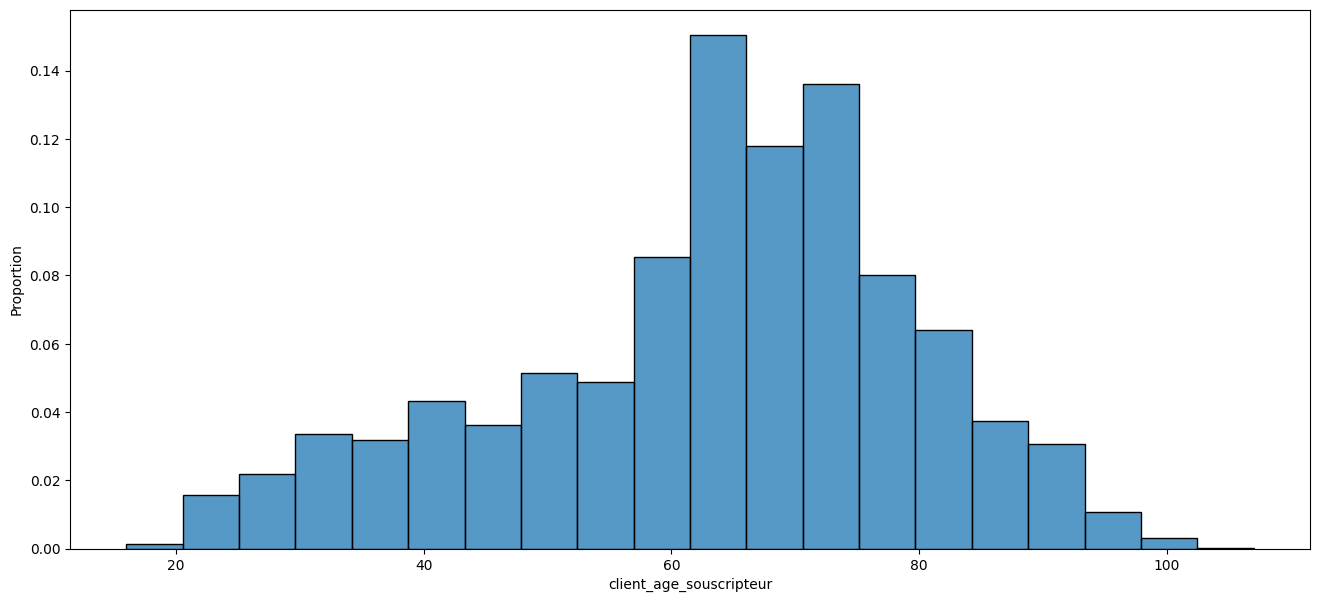

------  Analyse de la variable client_nb_enfants 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.2 
Médiane : 0.0 
Maximum : 10.0 
Unique values : 10.0


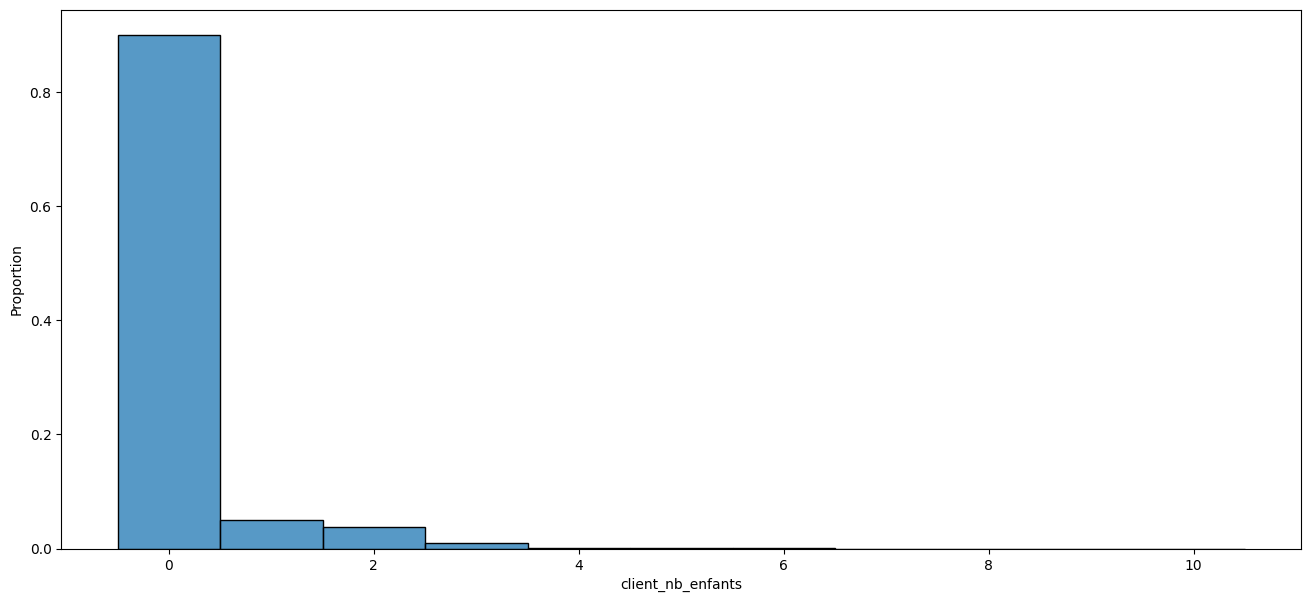

------  Analyse de la variable client_nb_assures_contrat 

Missing values : 0.0% 
Minimum : 1.0 
Moyenne : 1.5 
Médiane : 1.0 
Maximum : 12.0 
Unique values : 11.0


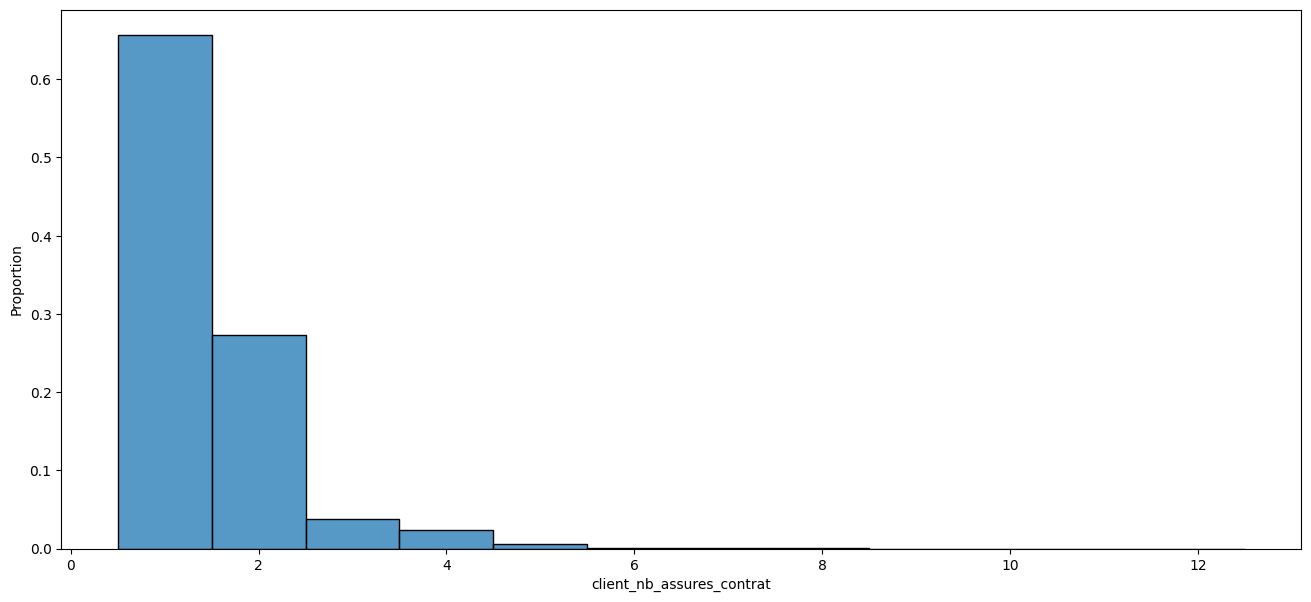

------  Analyse de la variable client_anciennete_contrat_annees 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 4.9 
Médiane : 2.0 
Maximum : 63.0 
Unique values : 61.0


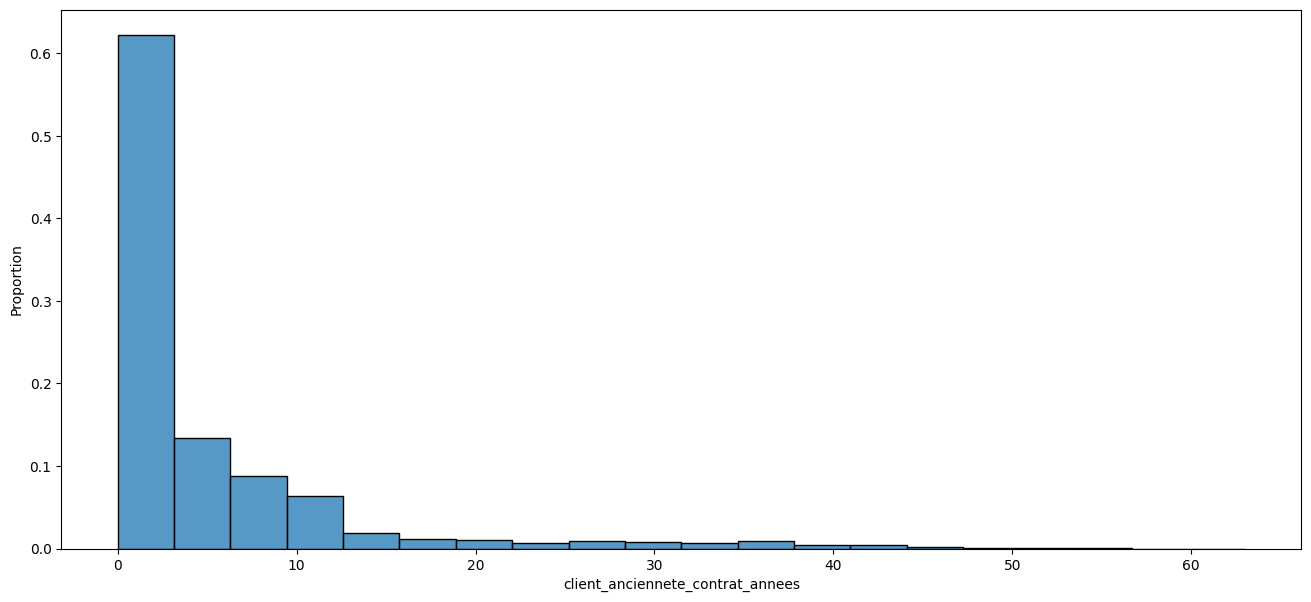

------  Analyse de la variable client_cotisations_annualisees_n_moins2 

Missing values : 45.9% 
Minimum : 138.0 
Moyenne : 1537.0 
Médiane : 1271.0 
Maximum : 15571.0 
Unique values : 4928.0


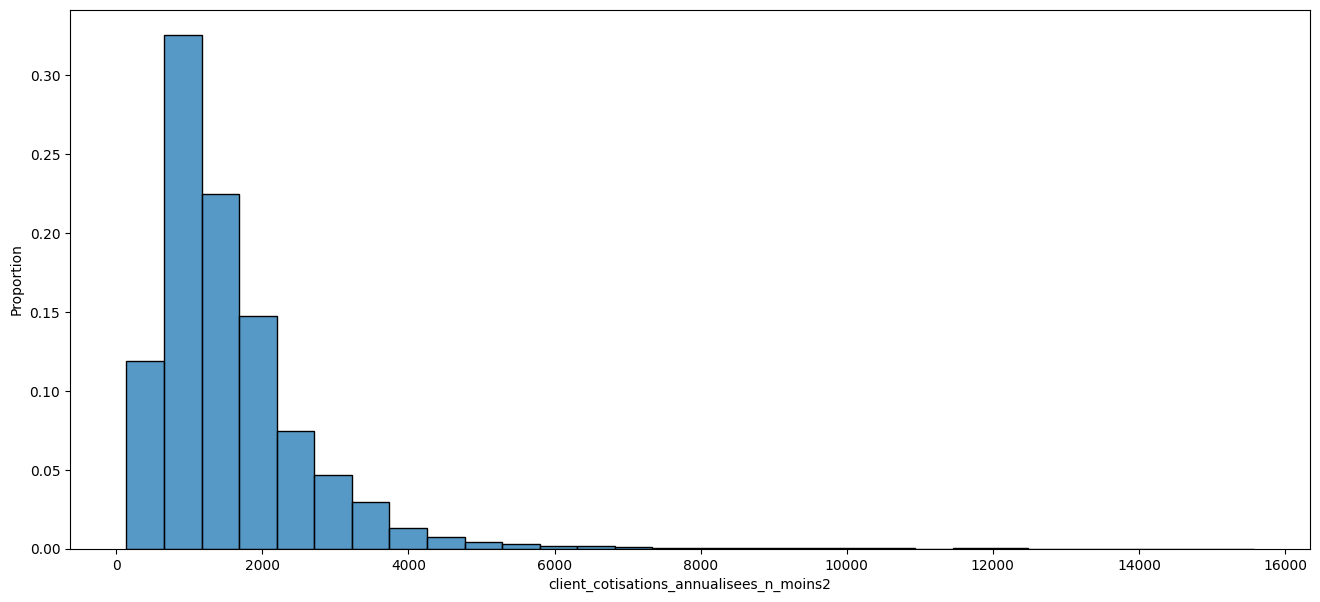

------  Analyse de la variable client_cotisations_annualisees_n_moins1 

Missing values : 28.4% 
Minimum : 141.0 
Moyenne : 1518.0 
Médiane : 1269.0 
Maximum : 16447.0 
Unique values : 5088.0


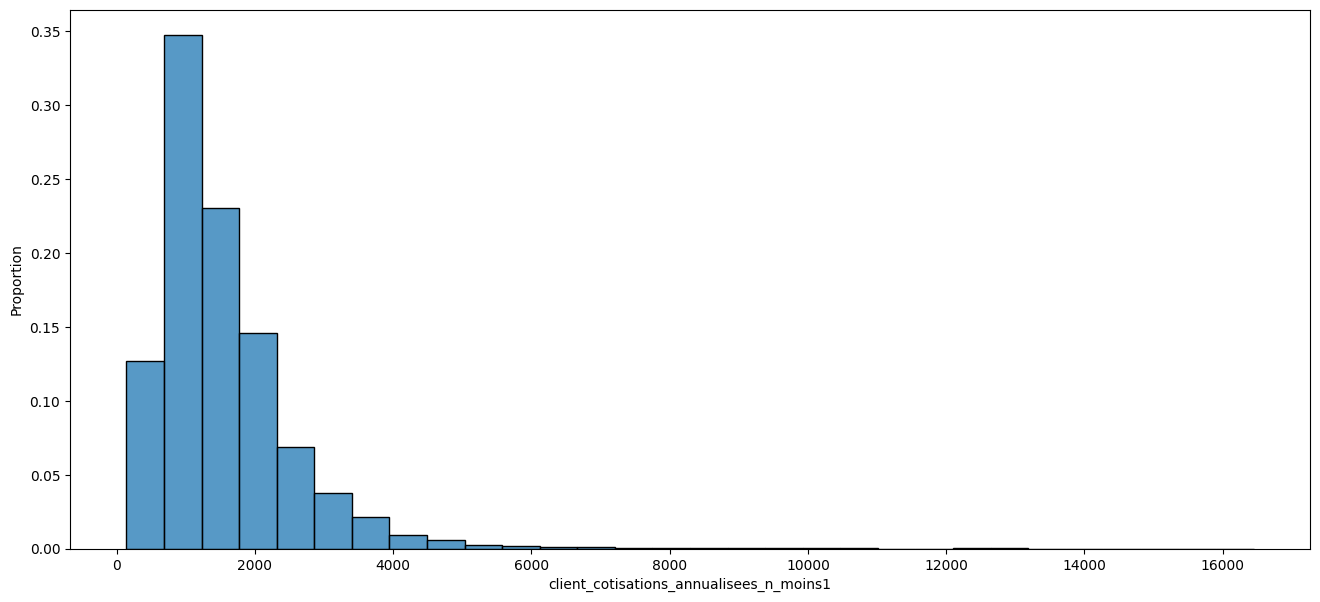

------  Analyse de la variable client_cotisations_annualisees_n 

Missing values : 0.0% 
Minimum : 138.0 
Moyenne : 1547.6 
Médiane : 1316.0 
Maximum : 17471.0 
Unique values : 5312.0


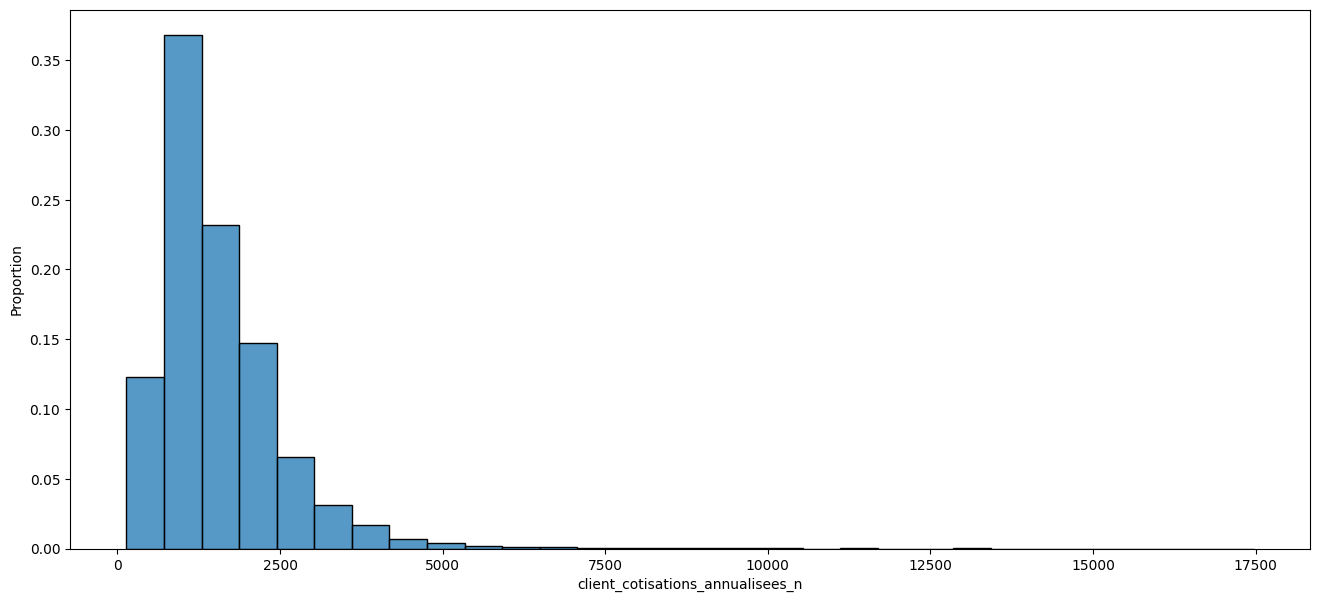

------  Analyse de la variable client_cotisations_annualisees_n_plus1 

Missing values : 0.0% 
Minimum : 138.0 
Moyenne : 1756.8 
Médiane : 1499.0 
Maximum : 19165.0 
Unique values : 5833.0


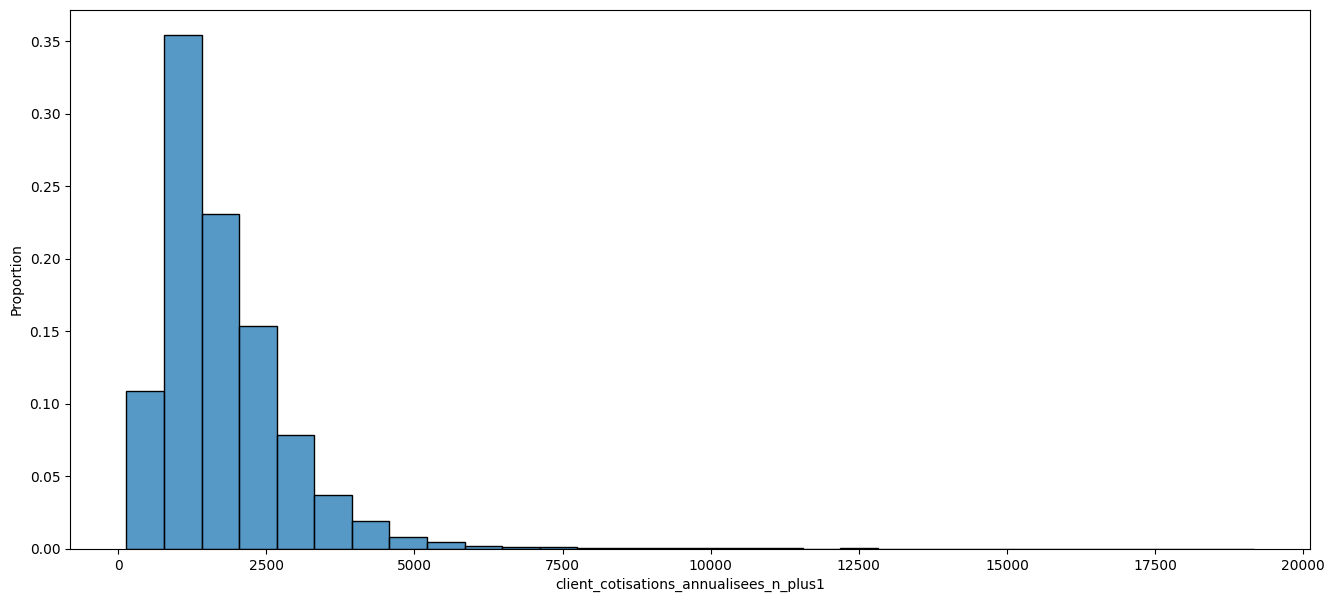

------  Analyse de la variable client_nps_note_reco_n 

Missing values : 94.4% 
Minimum : 0.0 
Moyenne : 7.7 
Médiane : 8.0 
Maximum : 10.0 
Unique values : 11.0


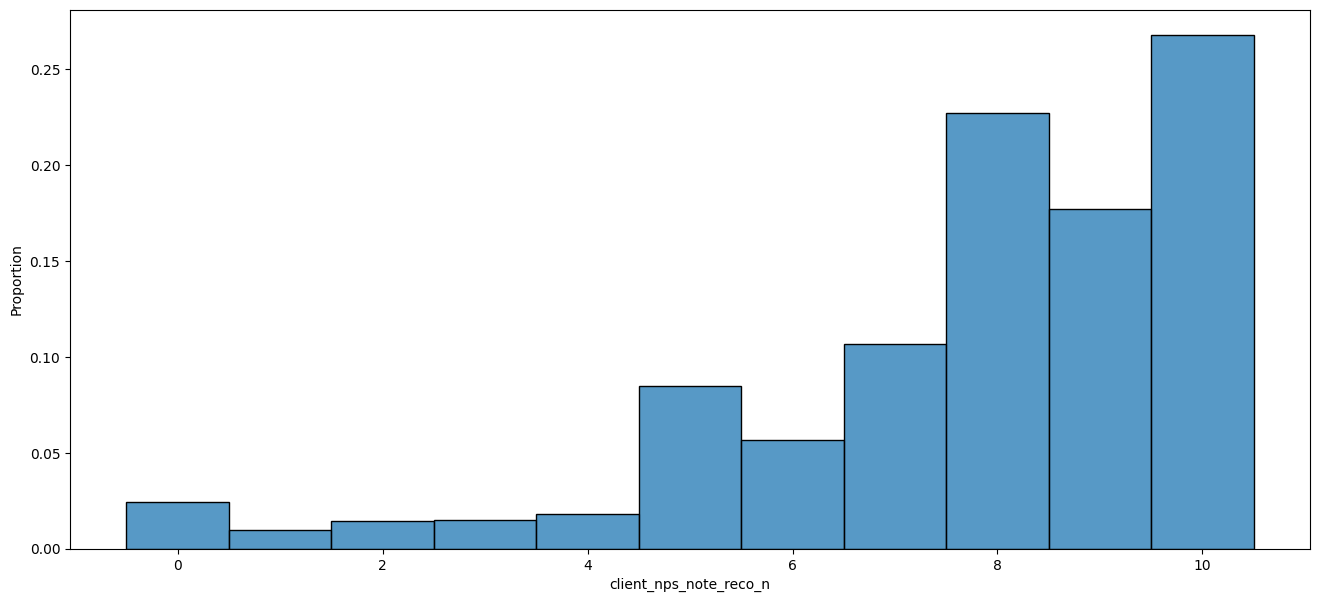

------  Analyse de la variable client_nps_note_reco_n_moins1 

Missing values : 95.8% 
Minimum : 0.0 
Moyenne : 7.6 
Médiane : 8.0 
Maximum : 10.0 
Unique values : 11.0


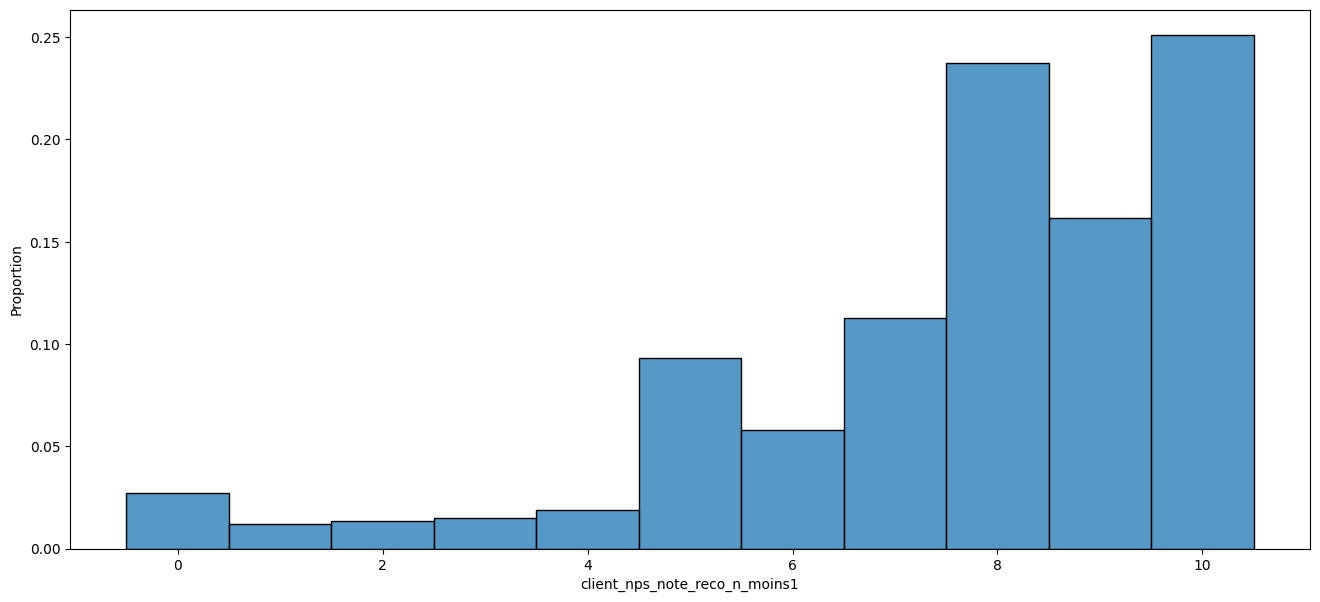

------  Analyse de la variable courtier_anciennete_annees 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 11.4 
Médiane : 10.0 
Maximum : 123.0 
Unique values : 43.0


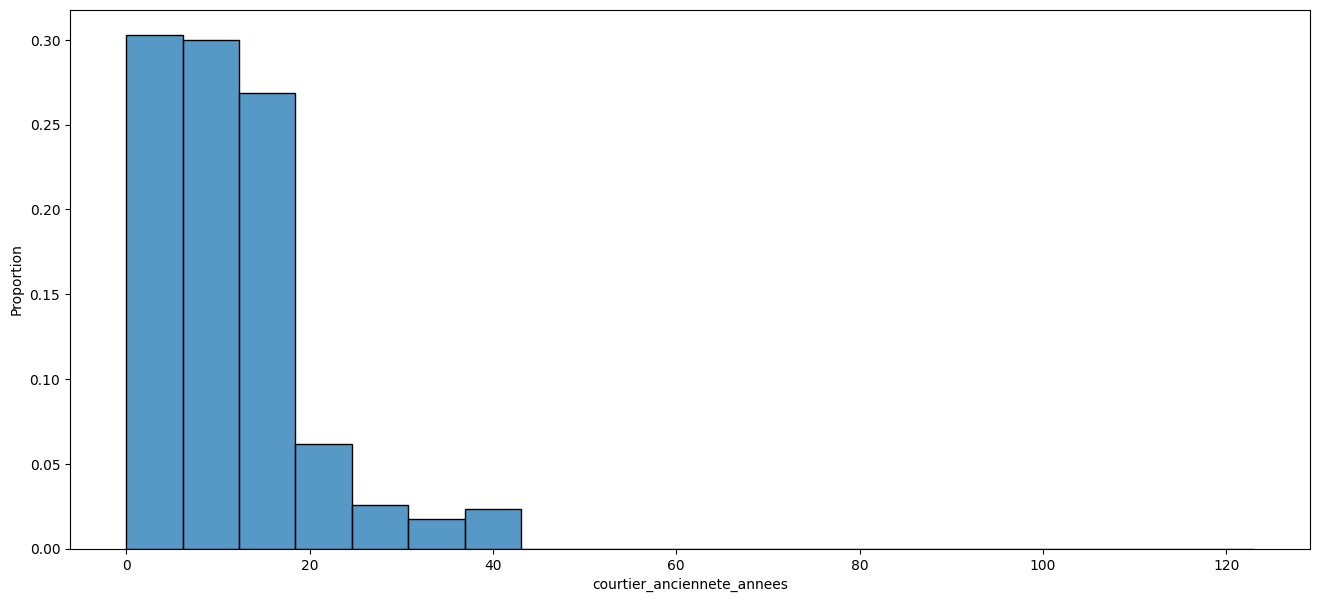

------  Analyse de la variable courtier_nb_affaires_n_moins1 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 473.2 
Médiane : 37.0 
Maximum : 3400.0 
Unique values : 139.0


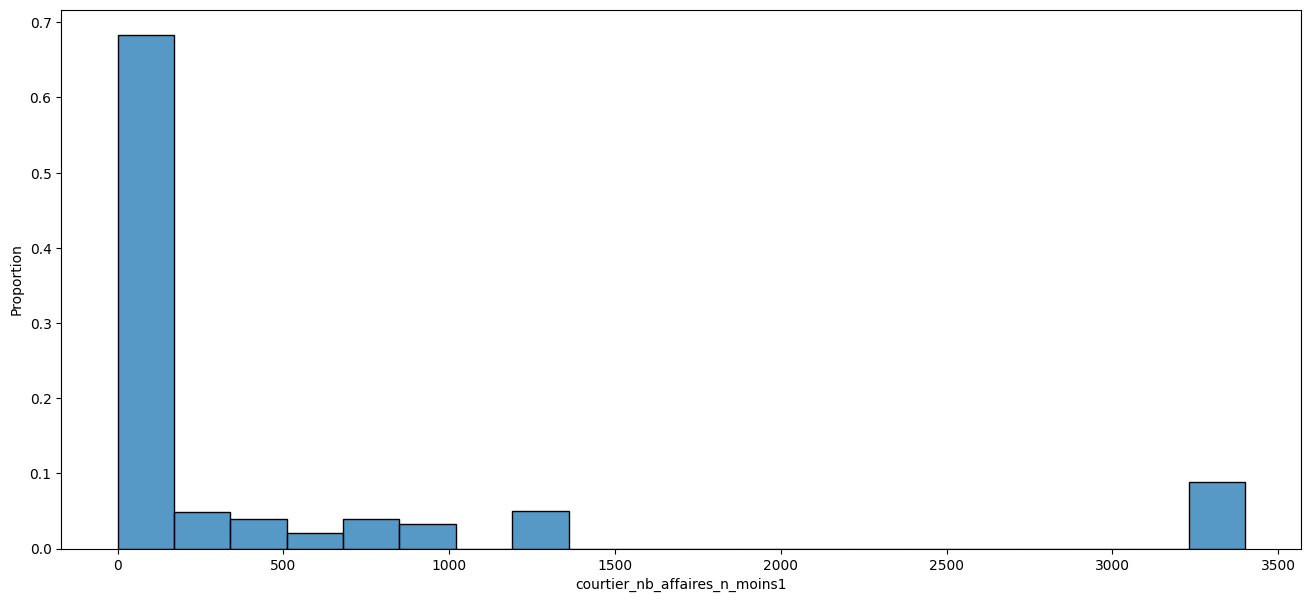

------  Analyse de la variable courtier_nb_radiations_n_moins1 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 285.1 
Médiane : 12.0 
Maximum : 1908.0 
Unique values : 87.0


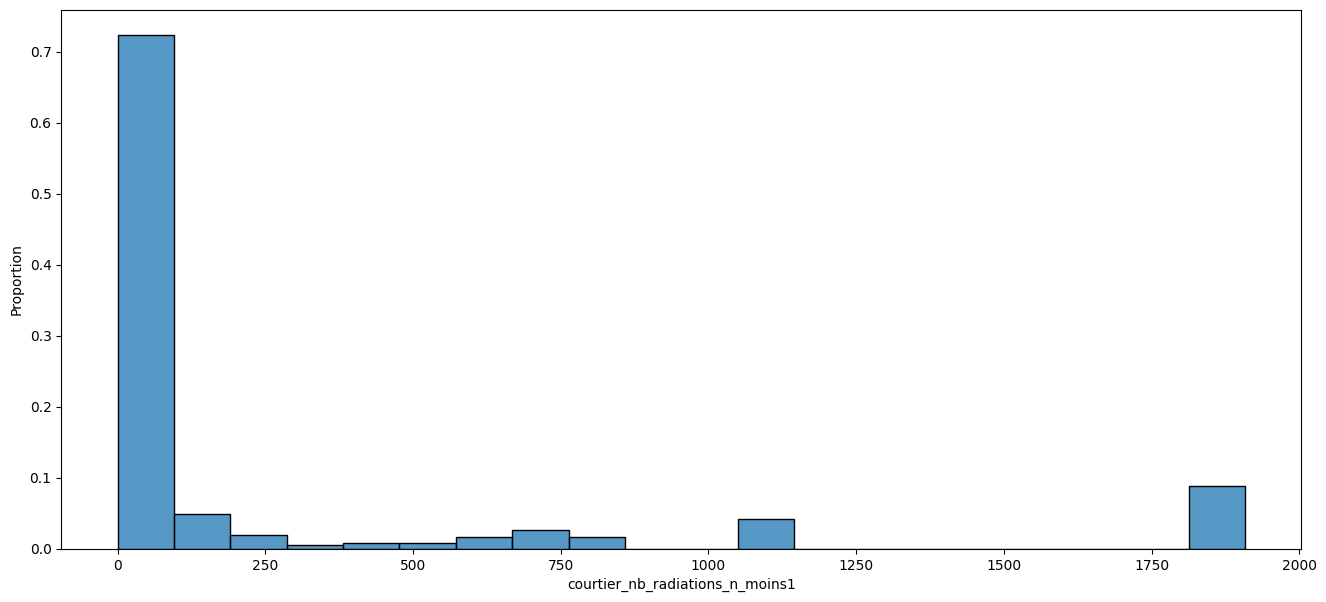

------  Analyse de la variable courtier_nb_affaires_n_moins2 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 355.0 
Médiane : 8.0 
Maximum : 2561.0 
Unique values : 98.0


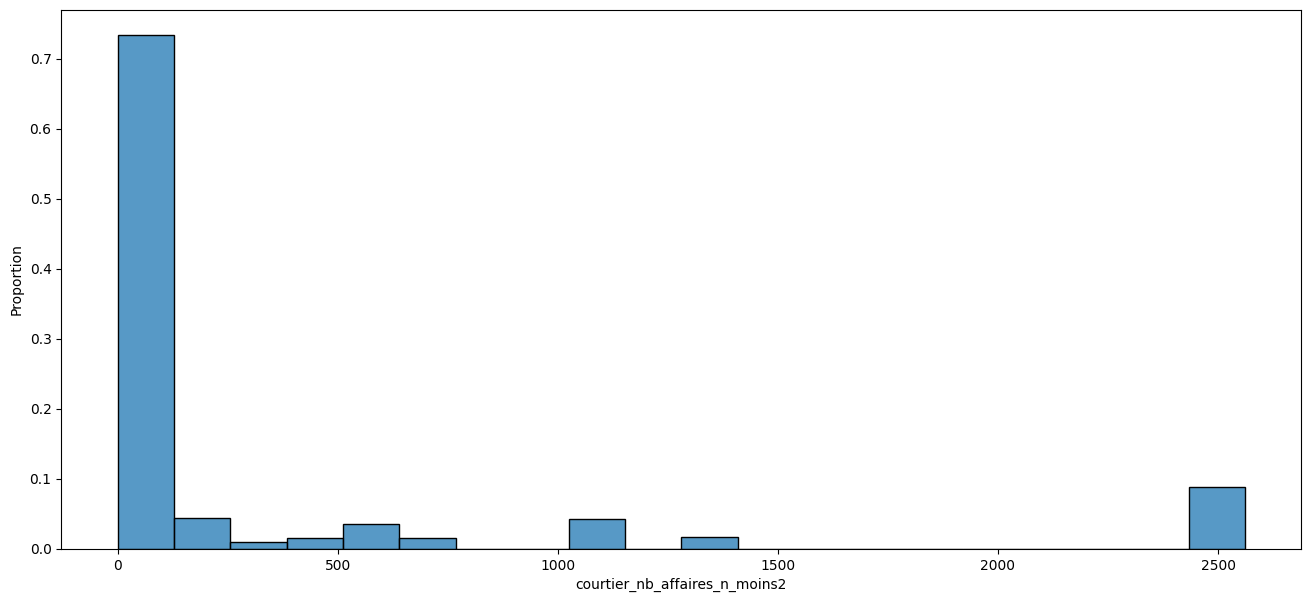

------  Analyse de la variable courtier_nb_radiations_n_moins2 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 304.2 
Médiane : 8.0 
Maximum : 2141.0 
Unique values : 87.0


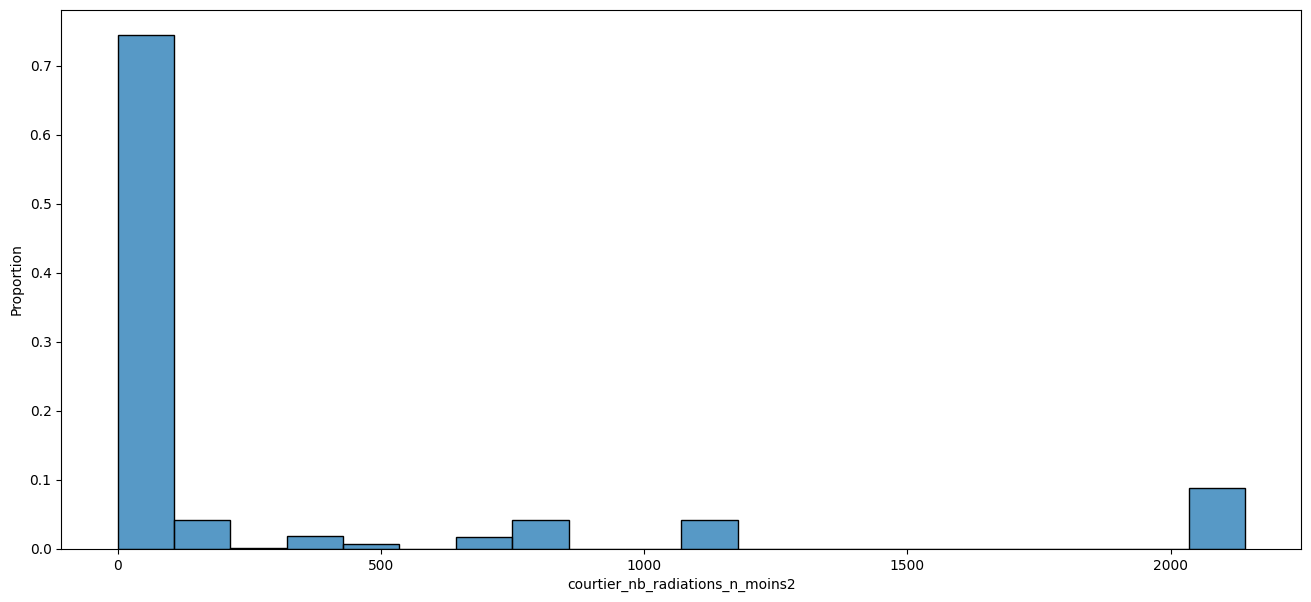

------  Analyse de la variable target_resiliation_6mois 

Missing values : 0.0% 
Minimum : 0.0 
Moyenne : 0.1 
Médiane : 0.0 
Maximum : 1.0 
Unique values : 2.0


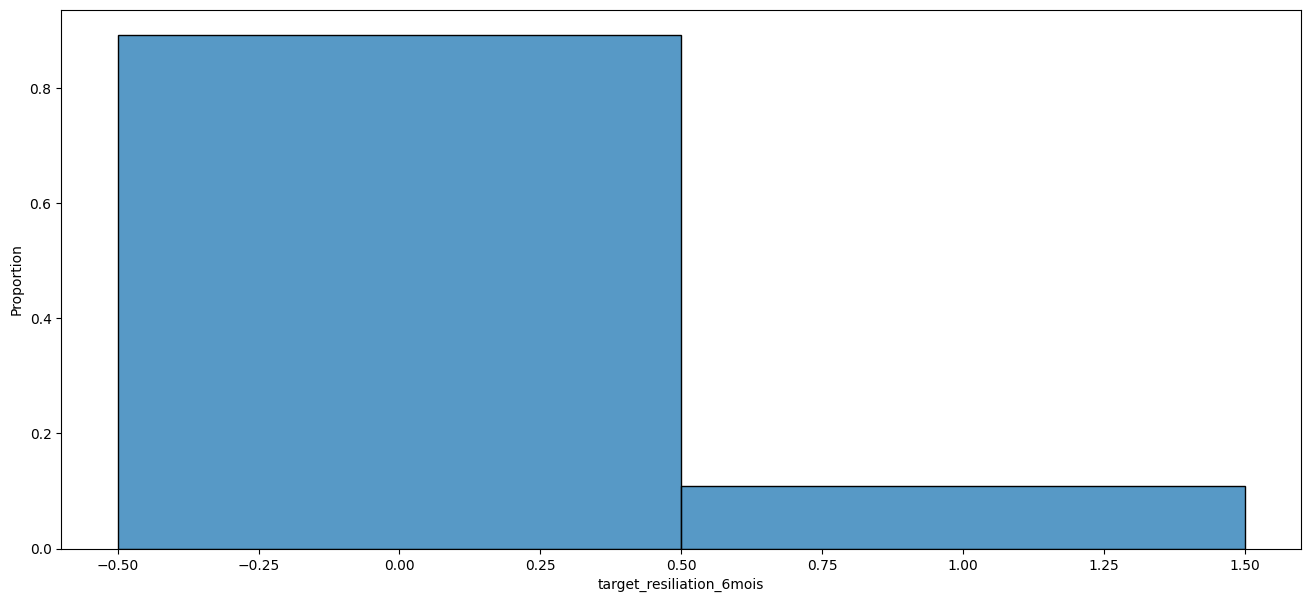

In [29]:
# Plot Numerical variables
TransformData.plotnum(
    data=df_portfolio, 
    numerical_variables_list=list_numerical
    )

In [84]:
# Specific tables
temp_df = df_portfolio[['client_produit']].groupby('client_produit').agg(
    nb = ('client_produit', 'size')
).reset_index()
temp_df['percent'] = 100*temp_df['nb']/df_portfolio.shape[0]
temp_df.sort_values(by='percent', inplace=True, ascending=False)
temp_df.head(10)

,client_produit,nb,percent
21,produit_29,32873,24.795589
29,produit_37,30020,22.643616
23,produit_30,8769,6.614319
24,produit_31,6614,4.988837
9,produit_18,6052,4.564929
13,produit_21,5537,4.176472
28,produit_36,5346,4.032404
25,produit_32,4871,3.674119
12,produit_20,3823,2.883629
31,produit_39,2914,2.197985


**Geographical Analysis**

The goal of this section is to study the geographical distribution of customers and identify (if they exist) some patterns with regard to the target variable.
-   Our geographical analysis will be conducted primarily at the departmental level, since there are some inconsistencies in the zip code
-   Question : The reason of inconsistencies in zip code.

The questions we are going to answer are the following :
-   Are there some departments with very high level of cancellations ?
-   Is there a link between the variable Zone tarifaire and the place of residence of the customers ?
-   What are the macroeconomic indicators in the departments with high level of cancellations

In [30]:
# Install libraries
%pip install folium # for dynamic maps
%pip install cartiflette # French Gov initiative to get geodata
%pip install geopandas # useful library for manipulating geographic data as DataFrame

# import libraries
import folium
import geopandas as gpd
from cartiflette import carti_download

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [folium]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.5/32.5 MB 53.5 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 65.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 26.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [cartiflette] [geopandas]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
# Download map with department-level data
departements = carti_download(
    values = ["France"],
    crs = 4326,
    borders = "DEPARTEMENT",
    vectorfile_format="topojson",
    simplification=50,
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022
)
departements['INSEE_DEP'] = departements['INSEE_DEP'].astype(str).str.zfill(2)
departements.head()

,id,INSEE_DEP,PAYS,LIBELLE_DEPARTEMENT,POPULATION,SOURCE,geometry
0,None,43,France,Haute-Loire,227570,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((3.89745 45.357, 3.89816 45.35682, 3...."
1,None,65,France,Hautes-Pyrénées,229567,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-0.09706 43.5822, -0.09734 43...."
2,None,29,France,Finistère,915090,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-3.97906 47.70396, -3.97949 47..."
3,None,22,France,Côtes-d'Armor,600582,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-3.20175 48.85197, -3.20213 48..."
4,None,38,France,Isère,1271166,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((5.1015 45.81356, 5.10373 45.81392, 5..."


In [32]:
# Analyze department dataset
departements.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   id                   0 non-null      object  
 1   INSEE_DEP            105 non-null    object  
 2   PAYS                 105 non-null    object  
 3   LIBELLE_DEPARTEMENT  105 non-null    object  
 4   POPULATION           105 non-null    int32   
 5   SOURCE               105 non-null    object  
 6   geometry             105 non-null    geometry
dtypes: geometry(1), int32(1), object(5)
memory usage: 5.5+ KB


In [33]:
# Analyze department dataset
departements[departements.duplicated(subset='INSEE_DEP')].head(100)

,id,INSEE_DEP,PAYS,LIBELLE_DEPARTEMENT,POPULATION,SOURCE,geometry
96,None,92,France,Hauts-de-Seine,1624357,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((-3.65355 50.32074, -3.66489 50.30822..."
97,None,93,France,Seine-Saint-Denis,1644903,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((-3.7016 50.64357, -3.70272 50.64702,..."
98,None,94,France,Val-de-Marne,1407124,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((-2.61405 50.28287, -2.60901 50.28138..."
99,None,75,France,Paris,2165423,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((-3.65355 50.32074, -3.65132 50.32553..."


In [34]:
# Analyze department dataset - duplicated values
departements.query('INSEE_DEP in ["75", "94", "93", "92"]')

,id,INSEE_DEP,PAYS,LIBELLE_DEPARTEMENT,POPULATION,SOURCE,geometry
73,None,92,France,Hauts-de-Seine,1624357,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((2.33189 48.81701, 2.32906 48.81378, ..."
79,None,93,France,Seine-Saint-Denis,1644903,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((2.31989 48.90045, 2.3196 48.90135, 2..."
82,None,94,France,Val-de-Marne,1407124,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((2.59178 48.80725, 2.59304 48.80686, ..."
95,None,75,France,Paris,2165423,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((2.33189 48.81701, 2.33246 48.81825, ..."
96,None,92,France,Hauts-de-Seine,1624357,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((-3.65355 50.32074, -3.66489 50.30822..."
97,None,93,France,Seine-Saint-Denis,1644903,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((-3.7016 50.64357, -3.70272 50.64702,..."
98,None,94,France,Val-de-Marne,1407124,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((-2.61405 50.28287, -2.60901 50.28138..."
99,None,75,France,Paris,2165423,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((-3.65355 50.32074, -3.65132 50.32553..."


In [35]:
# Analyze department dataset
departements.drop_duplicates(subset='INSEE_DEP', inplace=True)
departements.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 101 entries, 0 to 104
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   id                   0 non-null      object  
 1   INSEE_DEP            101 non-null    object  
 2   PAYS                 101 non-null    object  
 3   LIBELLE_DEPARTEMENT  101 non-null    object  
 4   POPULATION           101 non-null    int32   
 5   SOURCE               101 non-null    object  
 6   geometry             101 non-null    geometry
dtypes: geometry(1), int32(1), object(5)
memory usage: 5.9+ KB


Main conclusions of this preliminary analysis :
-   4 duplicated departments : 75, 94, 92, 93
-   We dropped the duplicated values (difficult to say if the remaining polygon are the correct ones)

__

 __

In [36]:
# Build the cancellation rate DataFrame
df_portfolio_aggregate_cancelation_rate = df_portfolio[['target_resiliation_6mois', 'client_departement']].groupby('client_departement').agg(
    nombre_client = ('target_resiliation_6mois', 'size'),
    nombre_resiliation = ('target_resiliation_6mois', 'sum'),
).reset_index()
df_portfolio_aggregate_cancelation_rate['taux_resiliation'] = (100*(df_portfolio_aggregate_cancelation_rate['nombre_resiliation']/df_portfolio_aggregate_cancelation_rate['nombre_client'])).round(2)
df_portfolio_aggregate_cancelation_rate.sort_values('taux_resiliation', ascending=False, inplace=True)
df_portfolio_aggregate_cancelation_rate['client_departement'] = df_portfolio_aggregate_cancelation_rate['client_departement'].astype(str).str.zfill(2)
df_portfolio_aggregate_cancelation_rate.head(100)

,client_departement,nombre_client,nombre_resiliation,taux_resiliation
42,40,608,136,22.37
64,62,1793,340,18.96
78,76,4249,792,18.64
27,27,1392,256,18.39
68,66,1161,205,17.66
...,...,...,...,...
1,01,3238,193,5.96
70,68,2586,122,4.72
76,74,9440,442,4.68
101,973,478,21,4.39


In [37]:
# Analyze the cancelation rate DataFrame
df_portfolio_aggregate_cancelation_rate.info()

<class 'pandas.core.frame.DataFrame'>
Index: 106 entries, 42 to 105
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   client_departement  106 non-null    object 
 1   nombre_client       106 non-null    int64  
 2   nombre_resiliation  106 non-null    int64  
 3   taux_resiliation    106 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 4.1+ KB


In [38]:
# Analyze the cancelation rate DataFrame
df_portfolio_aggregate_cancelation_rate[['nombre_client', 'nombre_resiliation', 'taux_resiliation']].describe()

,nombre_client,nombre_resiliation,taux_resiliation
count,106.000000,106.000000,106.000000
mean,1250.716981,136.320755,11.549623
std,1344.931464,127.042816,4.211667
min,1.000000,0.000000,0.000000
25%,411.500000,44.500000,9.717500
50%,859.500000,104.500000,11.855000
75%,1651.500000,172.250000,14.335000
max,9440.000000,792.000000,22.370000


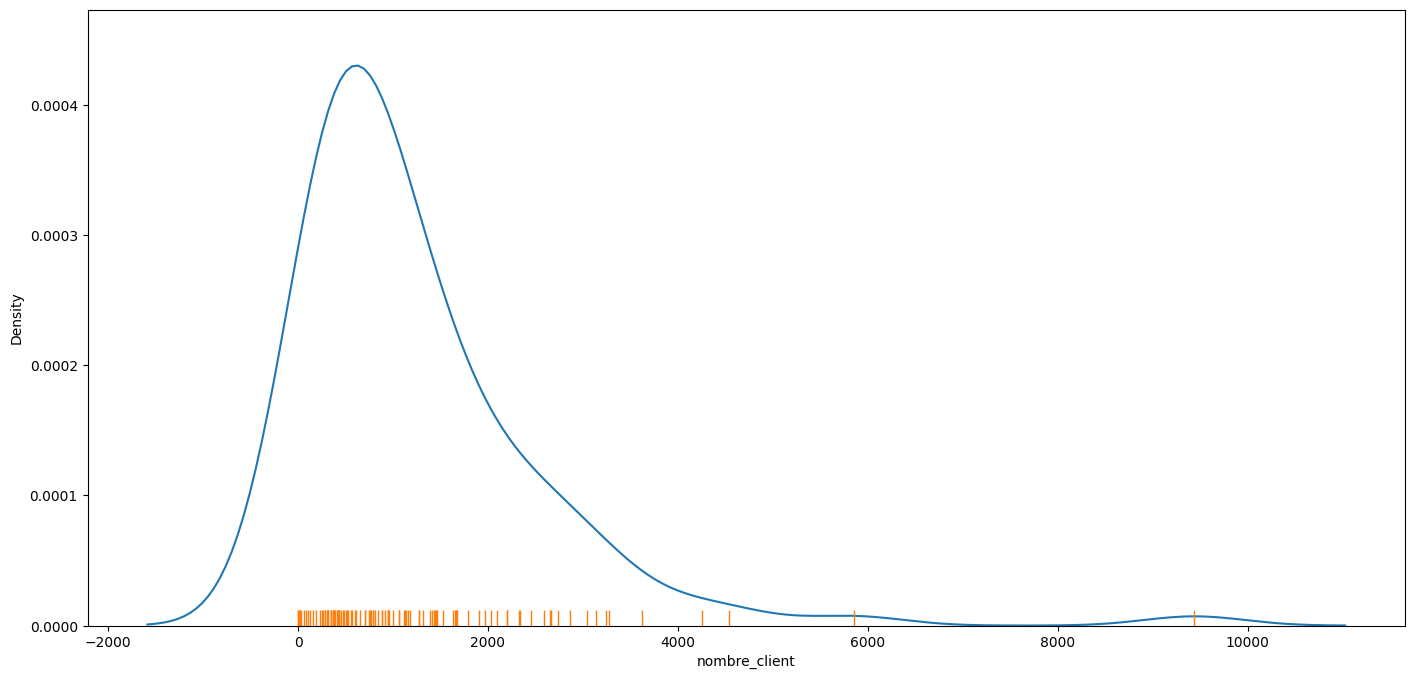

In [39]:
# Analyze the cancelation rate DataFrame
plt.figure(figsize=(17,8))
sns.kdeplot(data=df_portfolio_aggregate_cancelation_rate['nombre_client'])
sns.rugplot(data=df_portfolio_aggregate_cancelation_rate['nombre_client'])
plt.show()

In [40]:
# Analyze the cancelation rate DataFrame
df_portfolio_aggregate_cancelation_rate[df_portfolio_aggregate_cancelation_rate['nombre_client']<100]

,client_departement,nombre_client,nombre_resiliation,taux_resiliation
20,20,32,5,15.62
23,23,81,12,14.81
0,00,4,0,0.00
98,970,67,0,0.00
103,976,1,0,0.00
104,978,16,0,0.00
105,98,10,0,0.00


Main conclusions
-   Although unbalanced, the distribution of customers across departments is such than only three departments have less than 100 customers, with only 12 cancellations out of 81 customers in department 23.
-   There are huge customer pools in certain areas (>6000 customers)
-   Correctness of some values of department (e.g: 00)
-   We need to be careful when merging this dataset to the previous one

__

__

In [41]:
# Merging the datasets
inner_merge_geographic_data, outer_left_geographic_data, outer_right_geographic_data = TransformData.dataframe_merge(
    input_df1=departements, 
    input_df2=df_portfolio_aggregate_cancelation_rate,
    id_1='INSEE_DEP',
    id_2='client_departement'
    )

In [42]:
# Merging the datasets
outer_right_geographic_data.head()

,id,INSEE_DEP,PAYS,LIBELLE_DEPARTEMENT,POPULATION,SOURCE,geometry,client_departement,nombre_client,nombre_resiliation,taux_resiliation,_merge
0,NaN,NaN,NaN,NaN,NaN,NaN,None,00,4,0,0.00,right_only
20,NaN,NaN,NaN,NaN,NaN,NaN,None,20,32,5,15.62,right_only
98,NaN,NaN,NaN,NaN,NaN,NaN,None,970,67,0,0.00,right_only
104,NaN,NaN,NaN,NaN,NaN,NaN,None,978,16,0,0.00,right_only
105,NaN,NaN,NaN,NaN,NaN,NaN,None,98,10,0,0.00,right_only


In [43]:
# Merging the datasets
outer_right_geographic_data.shape

(5, 12)

In [44]:
# Merging the datasets
inner_merge_geographic_data.head()

,id,INSEE_DEP,PAYS,LIBELLE_DEPARTEMENT,POPULATION,SOURCE,geometry,client_departement,nombre_client,nombre_resiliation,taux_resiliation
0,None,43,France,Haute-Loire,227570,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((3.89745 45.357, 3.89816 45.35682, 3....",43,349,34,9.74
1,None,65,France,Hautes-Pyrénées,229567,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-0.09706 43.5822, -0.09734 43....",65,363,41,11.29
2,None,29,France,Finistère,915090,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-3.97906 47.70396, -3.97949 47...",29,1455,123,8.45
3,None,22,France,Côtes-d'Armor,600582,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-3.20175 48.85197, -3.20213 48...",22,791,88,11.13
4,None,38,France,Isère,1271166,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((5.1015 45.81356, 5.10373 45.81392, 5...",38,3135,278,8.87


In [45]:
# Merging the datasets
inner_merge_geographic_data.shape

(101, 11)

In [46]:
# Merging the datasets
outer_left_geographic_data.head(10)

,id,INSEE_DEP,PAYS,LIBELLE_DEPARTEMENT,POPULATION,SOURCE,geometry,client_departement,nombre_client,nombre_resiliation,taux_resiliation,_merge


In [47]:
# Merging the datasets
outer_left_geographic_data.shape

(0, 12)

Firsthand analysis :
-   Some departments from the portfolio dataset not matched with the cartiflette geodata : 00, 20, 97, 98
-   *Department 00*: has no correspondance. An error or omission in the Alptis dataset
-   *Department 20*:  has correspondence to Corse before 1976. By this year, the Corse region has been split in 2 departments, Haute-Corse (2B) and Corse du Sud (2A).
-   *Department 97*: Correspond to the DOM-TOM : 971 Guadeloupe, 972 Martinique, 973 Guyane, 974 La Réunion, 976 Mayotte
-   *Department 98*: Correspond either to Monaco (98000) or Nouméa (98846)

Transform the dataset to include these special cases :
-   *Department 00*: No further action. By the way, there is no cancellation by customers concerned
-   *Department 20*: Use a mapping tab to transform the value of department into either 2A or 2B using the code postal
-   *Department 97*: Take the three figures instead. 
-   *Department 98*: Are not part of France in the cartiflette project. Moreover, there are no resiliation in theses geographies. 

In [48]:
# Transforming unmatched departement from Potrfolio to match it with the cartiflette geodata
## Find corresponding lines in portfolio
df_transform_departement, _, _ = TransformData.dataframe_merge(
    input_df1=df_portfolio[list_categorical], 
    input_df2=outer_right_geographic_data[['client_departement', 'taux_resiliation']],
    id_1='client_departement',
    id_2='client_departement'
    )

In [49]:
# Transforming unmatched departement from Potrfolio to match it with the cartiflette geodata
## Find corresponding lines in portfolio
df_transform_departement.shape

(129, 33)

In [50]:
# Transforming unmatched departement from Potrfolio to match it with the cartiflette geodata
## Find corresponding lines in portfolio
df_transform_departement[df_transform_departement['client_departement']=='20']['client_code_postal'].unique()

array(['20090', '20144', '20176', '20118'], dtype=object)

In [51]:
# Transforming unmatched departement from Potrfolio to match it with the cartiflette geodata
## Find corresponding lines in portfolio
df_transform_departement[df_transform_departement['client_departement']=='20'].head()

,client_code,client_sexe_souscripteur,client_ro_souscripteur,client_code_postal,client_departement,client_departement_avant_changement_12_mois,client_a_conjoint,client_structure_familiale,client_a_garantie_prevoyance,client_produit,...,client_nps_verbatim_n_moins1,courtier_code_partenaire,courtier_code_apporteur,courtier_code_avant_changement_12_mois,courtier_reseau_courtage,courtier_segmentation_interne,courtier_type_commission,courtier_est_escompte,target_resiliation_6mois,taux_resiliation
13,5489842,F,SS,20090,20,nan,0.0,femme ss enfant,0,produit_8,...,NaN,102376,413498,nan,COURTIER CLASSIQUE,Potentiel,precompte,0,0,15.62
19,5836230,F,SS,20090,20,nan,0.0,femme ss enfant,0,produit_22,...,NaN,114101,431180,nan,COURTIER CLASSIQUE,Sommeil,NaN,0,0,15.62
36,8610617,M,SS,20090,20,nan,0.0,homme ss enfant,0,produit_15,...,NaN,87256,141667,140141.0,AFFAIRE DIRECTE,Alptis,precompte,0,0,15.62
50,9017135,F,SS,20144,20,nan,0.0,femme ss enfant,0,produit_2,...,NaN,123397,439069,nan,COURTIER CLASSIQUE,Opportuniste,precompte,0,0,15.62
57,9252223,M,SS,20090,20,nan,0.0,homme ss enfant,0,produit_17,...,NaN,115508,168001,nan,E_COURTIER,CMA,precompte,1,0,15.62


In [52]:
# Merging the datasets : we are interested in both the inner merged and the outer left to plot region with no customer
geographic_data = pd.concat([inner_merge_geographic_data, outer_left_geographic_data.drop('_merge', axis=1)], axis=0)
geographic_data.head()

,id,INSEE_DEP,PAYS,LIBELLE_DEPARTEMENT,POPULATION,SOURCE,geometry,client_departement,nombre_client,nombre_resiliation,taux_resiliation
0,None,43,France,Haute-Loire,227570.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((3.89745 45.357, 3.89816 45.35682, 3....",43,349,34,9.74
1,None,65,France,Hautes-Pyrénées,229567.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-0.09706 43.5822, -0.09734 43....",65,363,41,11.29
2,None,29,France,Finistère,915090.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-3.97906 47.70396, -3.97949 47...",29,1455,123,8.45
3,None,22,France,Côtes-d'Armor,600582.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-3.20175 48.85197, -3.20213 48...",22,791,88,11.13
4,None,38,France,Isère,1271166.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((5.1015 45.81356, 5.10373 45.81392, 5...",38,3135,278,8.87


In [53]:
# Merging the datasets : we are interested in both the inner merged and the outer left to plot region with no customer
geographic_data.shape

(101, 11)

In [54]:
# Merging the datasets : we are interested in both the inner merged and the outer left to plot region with no customer
geographic_data["nombre_client"] = geographic_data["nombre_client"].fillna(0).astype(int)
geographic_data["nombre_resiliation"] = geographic_data["nombre_resiliation"].fillna(0).astype(int)
geographic_data["taux_resiliation"] = geographic_data["taux_resiliation"].fillna(0).astype(int)
geographic_data.sort_values("taux_resiliation",ascending=False).head(100)

,id,INSEE_DEP,PAYS,LIBELLE_DEPARTEMENT,POPULATION,SOURCE,geometry,client_departement,nombre_client,nombre_resiliation,taux_resiliation
26,None,40,France,Landes,413690.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((-0.24252 43.58483, -0.24347 43.58454...",40,608,136,22
6,None,27,France,Eure,599507.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((0.29687 49.42992, 0.30995 49.43098, ...",27,1392,256,18
63,None,62,France,Pas-de-Calais,1465278.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((3.09028 50.05379, 3.08814 50.05065, ...",62,1793,340,18
65,None,76,France,Seine-Maritime,1255633.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((0.33836 49.44543, 0.33879 49.4501, 0...",76,4249,792,18
91,None,66,France,Pyrénées-Orientales,479979.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((1.78613 42.57368, 1.78718 42.5...",66,1161,205,17
...,...,...,...,...,...,...,...,...,...,...,...
11,None,74,France,Haute-Savoie,826094.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((6.80235 45.77858, 6.80069 45.77969, ...",74,9440,442,4
44,None,68,France,Haut-Rhin,767086.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((7.13026 47.50295, 7.13157 47.50344, ...",68,2586,122,4
98,None,973,France,Guyane,281678.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-0.8533 42.0536, -0.85235 42.0...",973,478,21,4
96,None,971,France,Guadeloupe,384239.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-4.64883 42.07408, -4.64826 42...",971,3277,125,3


In [59]:
# Plotting the cancellation rate
m = folium.Map(location=[46.8, 2.5], zoom_start=5, tiles="cartodbpositron")
folium.Choropleth(
    geo_data=geographic_data.to_json(),
    name="Taux de résiliation",
    data=geographic_data,
    columns=["INSEE_DEP", "taux_resiliation"],
    key_on="feature.properties.INSEE_DEP",
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.2,
    nan_fill_color="lightgrey",
    legend_name="Taux de résiliation"
).add_to(m)

gjson = folium.GeoJson(
    geographic_data.to_json(),
    name="Détails départements",
    tooltip=folium.GeoJsonTooltip(
        fields=["INSEE_DEP", "nombre_client", "nombre_resiliation", "taux_resiliation"],
        aliases=["INSEE", "Nb clients", "Nb résil.", "Taux (0-1)"],
        localize=True,
        labels=True,
        style=("background-color: white; color: #333333;")
    ),
    popup=folium.GeoJsonPopup(
        fields=["insee_com", "nombre_client", "nombre_resiliation", "taux_resiliation"],
        aliases=["INSEE", "Nb clients", "Nb résil.", "Taux de résiliation"],
        localize=True,
    )
)
folium.LayerControl().add_to(m)
m.save("Carte des résiliations.html")
m = None

___

**Map customer distribution**

In [62]:
# Build the geo distribution DataFrame
df_portfolio_geo_distribution = df_portfolio[['client_code', 'client_departement']].groupby('client_departement').agg(
    nombre_client = ('client_code', 'size'),
).reset_index()
df_portfolio_geo_distribution['customer_size'] = (100*(df_portfolio_geo_distribution['nombre_client']/df_portfolio.shape[0])).round(2)
df_portfolio_geo_distribution.sort_values('customer_size', ascending=False, inplace=True)
df_portfolio_geo_distribution['client_departement'] = df_portfolio_geo_distribution['client_departement'].astype(str).str.zfill(2)
df_portfolio_geo_distribution.head(100)

,client_departement,nombre_client,customer_size
76,74,9440,7.12
71,69,5852,4.41
77,75,4534,3.42
78,76,4249,3.20
36,34,3622,2.73
...,...,...,...
31,2B,193,0.15
30,2A,157,0.12
15,15,122,0.09
50,48,102,0.08


In [63]:
# Merging the datasets
inner_merge_geographic_data, outer_left_geographic_data, outer_right_geographic_data = TransformData.dataframe_merge(
    input_df1=departements, 
    input_df2=df_portfolio_geo_distribution,
    id_1='INSEE_DEP',
    id_2='client_departement'
    )

In [67]:
# Merging the datasets : we are interested in both the inner merged and the outer left to plot region with no customer
geographic_data = pd.concat([inner_merge_geographic_data, outer_left_geographic_data.drop('_merge', axis=1)], axis=0)
geographic_data.head()

,id,INSEE_DEP,PAYS,LIBELLE_DEPARTEMENT,POPULATION,SOURCE,geometry,client_departement,nombre_client,customer_size
0,None,43,France,Haute-Loire,227570.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((3.89745 45.357, 3.89816 45.35682, 3....",43,349,0.26
1,None,65,France,Hautes-Pyrénées,229567.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-0.09706 43.5822, -0.09734 43....",65,363,0.27
2,None,29,France,Finistère,915090.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-3.97906 47.70396, -3.97949 47...",29,1455,1.10
3,None,22,France,Côtes-d'Armor,600582.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-3.20175 48.85197, -3.20213 48...",22,791,0.60
4,None,38,France,Isère,1271166.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((5.1015 45.81356, 5.10373 45.81392, 5...",38,3135,2.36


In [68]:
# Merging the datasets : we are interested in both the inner merged and the outer left to plot region with no customer
geographic_data["nombre_client"] = geographic_data["nombre_client"].fillna(0).astype(int)
geographic_data["customer_size"] = geographic_data["customer_size"].fillna(0).astype(float)
geographic_data.sort_values("customer_size",ascending=False).head(100)

,id,INSEE_DEP,PAYS,LIBELLE_DEPARTEMENT,POPULATION,SOURCE,geometry,client_departement,nombre_client,customer_size
11,None,74,France,Haute-Savoie,826094.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((6.80235 45.77858, 6.80069 45.77969, ...",74,9440,7.12
78,None,69,France,Rhône,1875747.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((4.75714 45.45561, 4.75607 45.45675, ...",69,5852,4.41
95,None,75,France,Paris,2165423.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((2.33189 48.81701, 2.33246 48.81825, ...",75,4534,3.42
65,None,76,France,Seine-Maritime,1255633.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((0.33836 49.44543, 0.33879 49.4501, 0...",76,4249,3.20
28,None,34,France,Hérault,1175623.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((3.24006 43.21277, 3.23842 43.2...",34,3622,2.73
...,...,...,...,...,...,...,...,...,...,...
52,None,2B,France,Haute-Corse,181933.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((8.5733 42.38153, 8.57418 42.38...",2B,193,0.15
57,None,2A,France,Corse-du-Sud,158507.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((9.38187 41.50903, 9.3813 41.50...",2A,157,0.12
49,None,15,France,Cantal,144692.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((2.06288 44.97661, 2.06561 44.97681, ...",15,122,0.09
21,None,48,France,Lozère,76604.0,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((3.86262 44.74396, 3.86259 44.74342, ...",48,102,0.08


In [71]:
# Plotting the cancellation rate
m = folium.Map(location=[46.8, 2.5], zoom_start=5, tiles="cartodbpositron")
folium.Choropleth(
    geo_data=geographic_data.to_json(),
    name="Répartition des clients",
    data=geographic_data,
    columns=["INSEE_DEP", "customer_size"],
    key_on="feature.properties.INSEE_DEP",
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.2,
    nan_fill_color="lightgrey",
    legend_name="Répartition des clients"
).add_to(m)

gjson = folium.GeoJson(
    geographic_data.to_json(),
    name="Détails départements",
    tooltip=folium.GeoJsonTooltip(
        fields=["INSEE_DEP", "nombre_client", "customer_size"],
        aliases=["INSEE", "Nb clients", "Répartition (0-1)"],
        localize=True,
        labels=True,
        style=("background-color: white; color: #333333;")
    ),
    popup=folium.GeoJsonPopup(
        fields=["insee_com", "nombre_client", "customer_size"],
        aliases=["INSEE", "Nb clients", "Répartition des clients"],
        localize=True,
    )
)
folium.LayerControl().add_to(m)
m.save("Répartition clients.html")
m = None

**Testing the link between 'client_zone_tarifaire'/'client_type_zone_tarifaire' and 'client_code_postal'**

In [56]:
# Groupby zone tariafire and commune
df_portfolio_test = df_portfolio[['client_code', 'client_code_postal', 'client_zone_tarifaire']].groupby(['client_code_postal']).agg(
    nombre_zone_tarifaire = ('client_zone_tarifaire', 'nunique'),
).reset_index()
df_portfolio_test.sort_values(by='nombre_zone_tarifaire', ascending=False, inplace=True)
df_portfolio_test.head(10)

,client_code_postal,nombre_zone_tarifaire
5029,75017,39
4942,74100,39
1934,33000,39
5027,75015,39
4609,69003,38
5023,75011,38
4616,69100,37
6406,97200,36
4878,73100,36
258,06000,36


In [57]:
# Groupby zone tariafire and commune
df_portfolio_test = df_portfolio[['client_code', 'client_code_postal', 'client_type_zone_tarifaire']].groupby(['client_code_postal']).agg(
    nombre_zone_tarifaire = ('client_type_zone_tarifaire', 'nunique'),
).reset_index()
df_portfolio_test.sort_values(by='nombre_zone_tarifaire', ascending=False, inplace=True)
df_portfolio_test.head(10)

,client_code_postal,nombre_zone_tarifaire
1934,33000,41
5029,75017,40
5027,75015,39
4942,74100,39
4609,69003,38
5023,75011,38
4616,69100,38
6406,97200,37
4878,73100,37
258,06000,36


Conclusions :
-   There is no rationale of geographical distribution in the 'Zone tarifaire' or 'Type zone tarifaire'
-   Some areas such as Bordeaux (33000), Paris 17 (75017) have almost 40 different 'zone tarifaire'
-   Question to Alptis - How is this variable computed ?

#### Correlation analysis

In this section, we are dealing with the correlation between variables. We consider two sides in this analysis :
-   Correlation between the target and the features
-   Correlation between features